<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/Score_Crediticio_Modelos_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Modelos de Score Crediticio: Teoría y Práctica en Python

**Notebook para clase — Machine Learning aplicado al riesgo de crédito**

En este notebook construimos un **score crediticio** (probabilidad de incumplimiento / default) usando el dataset clásico **German Credit** (disponible en OpenML vía `scikit-learn`). Cubrimos, con **teoría matemática, ecuaciones, código y gráficas**, los siguientes modelos:

| # | Modelo | Familia |
|---|--------|---------|
| 1 | Regresión Logística | Lineal / GLM |
| 2 | Análisis Discriminante (LDA y QDA) | Generativo |
| 3 | Naive Bayes | Generativo |
| 4 | Árbol de Decisión (CART) | Árboles |
| 5 | Bagging | Ensamble (paralelo) |
| 6 | Random Forest | Ensamble (paralelo) |
| 7 | Boosting (AdaBoost y Gradient Boosting) | Ensamble (secuencial) |
| 8 | Máquina de Soporte Vectorial (SVM) | Margen máximo |
| 9 | Red Neuronal (MLP) | Deep Learning |

Al final comparamos **todos los modelos** en una tabla con **Accuracy, F1-Score, AUC, Log-Loss (entropía cruzada)**, más curvas ROC y gráficas comparativas.

---

## 1. El problema del score crediticio

Un banco observa características $\mathbf{x} \in \mathbb{R}^p$ de un solicitante (edad, ingresos, historial, monto del crédito...) y quiere estimar la probabilidad de que sea **mal pagador**:

$$P(Y = 1 \mid \mathbf{X} = \mathbf{x})$$

donde $Y=1$ es *default* (mal crédito) y $Y=0$ es buen crédito. El **score** típicamente es una transformación monótona de esa probabilidad, por ejemplo:

$$\text{Score} = A - B \cdot \ln\left(\frac{P(Y=1\mid \mathbf{x})}{1 - P(Y=1\mid \mathbf{x})}\right)$$

(escala de puntos sobre el *log-odds*, como en los scorecards FICO). Es un problema de **clasificación binaria supervisada**.

In [1]:
# ==========================================================
# Instalación y librerías
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, log_loss, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, classification_report)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Librerías cargadas ✅")

Librerías cargadas ✅


## 2. Datos: German Credit (Statlog)

Dataset clásico de riesgo de crédito: **1,000 solicitantes**, 20 variables (estado de la cuenta, duración del crédito, historial, propósito, monto, empleo, edad, etc.) y la etiqueta `good` / `bad`.

Lo cargamos directamente desde **OpenML** con `sklearn` (funciona en Colab sin descargar archivos).

In [2]:
# ==========================================================
# Carga del dataset German Credit desde OpenML
# ==========================================================
data = fetch_openml("credit-g", version=1, as_frame=True, parser="auto")
df = data.frame.copy()

# Variable objetivo: 1 = bad (default), 0 = good
df["target"] = (df["class"] == "bad").astype(int)
df = df.drop(columns=["class"])

print("Dimensiones:", df.shape)
print("\nDistribución de la variable objetivo:")
print(df["target"].value_counts(normalize=True).rename({0: "good (0)", 1: "bad (1)"}))
df.head()

Dimensiones: (1000, 21)

Distribución de la variable objetivo:
target
good (0)    0.7
bad (1)     0.3
Name: proportion, dtype: float64


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,0
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,1


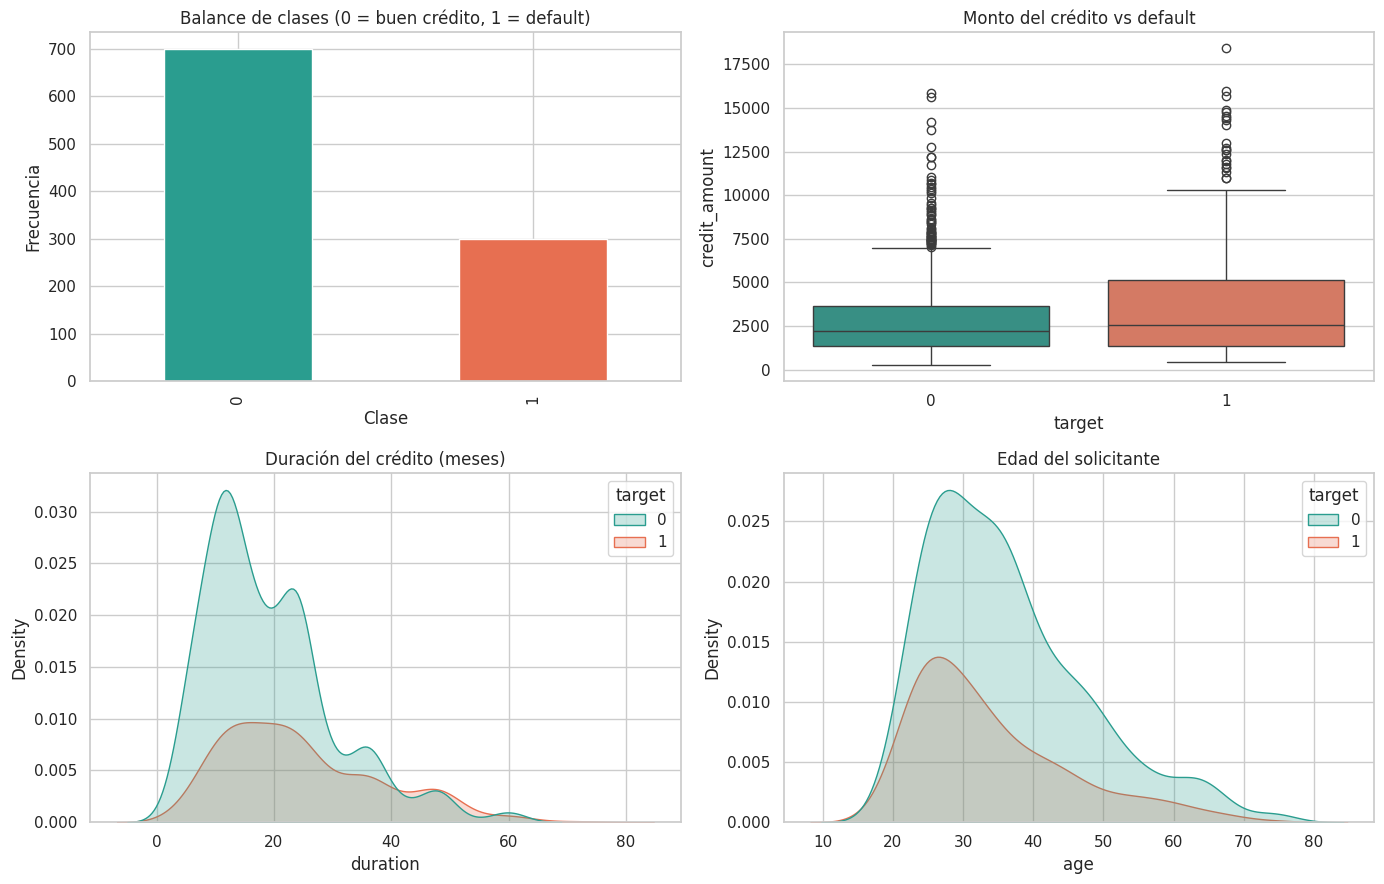

In [3]:
# ==========================================================
# Análisis exploratorio (EDA) rápido
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Balance de clases
df["target"].value_counts().plot(kind="bar", ax=axes[0,0], color=["#2a9d8f", "#e76f51"])
axes[0,0].set_title("Balance de clases (0 = buen crédito, 1 = default)")
axes[0,0].set_xlabel("Clase"); axes[0,0].set_ylabel("Frecuencia")

# 2. Monto del crédito por clase
sns.boxplot(data=df, x="target", y="credit_amount", ax=axes[0,1], hue="target",
            palette=["#2a9d8f", "#e76f51"], legend=False)
axes[0,1].set_title("Monto del crédito vs default")

# 3. Duración por clase
sns.kdeplot(data=df, x="duration", hue="target", fill=True, ax=axes[1,0],
            palette=["#2a9d8f", "#e76f51"])
axes[1,0].set_title("Duración del crédito (meses)")

# 4. Edad por clase
sns.kdeplot(data=df, x="age", hue="target", fill=True, ax=axes[1,1],
            palette=["#2a9d8f", "#e76f51"])
axes[1,1].set_title("Edad del solicitante")

plt.tight_layout(); plt.show()

### 2.1 Preprocesamiento

- **Variables numéricas** → estandarización: $z = \dfrac{x - \mu}{\sigma}$ (crítico para SVM, redes neuronales, regresión logística regularizada).
- **Variables categóricas** → *one-hot encoding*: cada categoría se convierte en una variable indicadora $\{0,1\}$.
- **Partición train/test** estratificada 70/30 para evaluar generalización:

$$\mathcal{D}_{\text{total}} = \mathcal{D}_{\text{train}} \cup \mathcal{D}_{\text{test}}, \qquad \mathcal{D}_{\text{train}} \cap \mathcal{D}_{\text{test}} = \varnothing$$

In [4]:
# ==========================================================
# Preprocesamiento
# ==========================================================
X = df.drop(columns=["target"])
y = df["target"]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
print(f"Numéricas ({len(num_cols)}):", num_cols)
print(f"Categóricas ({len(cat_cols)}):", cat_cols)

preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

print(f"\nTrain: {X_train.shape[0]} obs | Test: {X_test.shape[0]} obs")

Numéricas (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categóricas (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Train: 700 obs | Test: 300 obs


## 3. Métricas de evaluación (teoría)

A partir de la **matriz de confusión**:

|  | Predicho 0 | Predicho 1 |
|---|---|---|
| **Real 0** | TN | FP |
| **Real 1** | FN | TP |

**Accuracy** (exactitud):
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precisión y Recall (sensibilidad):**
$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

**F1-Score** — media armónica de precisión y recall (clave con clases desbalanceadas, como en crédito donde los defaults son minoría):
$$F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$

**Log-Loss / Entropía cruzada** — mide la calidad de las **probabilidades** predichas $\hat{p}_i$:
$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \ln \hat{p}_i + (1-y_i)\ln(1-\hat{p}_i)\Big]$$

Es la esperanza empírica de la **entropía cruzada** $H(p,q) = -\sum_x p(x)\ln q(x)$ entre la distribución real y la predicha. **Menor es mejor**.

**AUC-ROC** — probabilidad de que el modelo ordene correctamente un par (default, no-default) aleatorio:
$$\text{AUC} = P\big(\hat{p}(\mathbf{x}_{\text{default}}) > \hat{p}(\mathbf{x}_{\text{no default}})\big)$$

En riesgo de crédito el AUC se relaciona con el **índice de Gini** del scorecard: $\text{Gini} = 2\cdot\text{AUC} - 1$.

In [5]:
# ==========================================================
# Funciones auxiliares: entrenar, evaluar y graficar
# ==========================================================
resultados = {}   # aquí guardamos las métricas de todos los modelos
probs_test = {}   # probabilidades para curvas ROC

def evaluar_modelo(nombre, modelo, plot_cm=True):
    '''Entrena un pipeline (preproc + modelo), evalúa en test y guarda métricas.'''
    pipe = Pipeline([("prep", preproc), ("clf", modelo)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:  # SVM sin probability usa decision_function
        from scipy.special import expit
        y_prob = expit(pipe.decision_function(X_test))

    resultados[nombre] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "AUC":       roc_auc_score(y_test, y_prob),
        "LogLoss (entropía)": log_loss(y_test, y_prob),
    }
    probs_test[nombre] = y_prob

    print(f"===== {nombre} =====")
    for k, v in resultados[nombre].items():
        print(f"  {k:>20}: {v:.4f}")

    if plot_cm:
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                               display_labels=["Good (0)", "Bad (1)"]).plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"Matriz de confusión — {nombre}")
        plt.show()
    return pipe

print("Funciones listas ✅")

Funciones listas ✅


---
# 4. Regresión Logística

### Teoría

Modelamos el **log-odds** (logit) como función lineal de las covariables:

$$\ln\left(\frac{P(Y=1\mid\mathbf{x})}{1-P(Y=1\mid\mathbf{x})}\right) = \beta_0 + \boldsymbol{\beta}^\top \mathbf{x}$$

Despejando, la probabilidad es la **función sigmoide**:

$$P(Y=1\mid\mathbf{x}) = \sigma(\beta_0 + \boldsymbol{\beta}^\top\mathbf{x}) = \frac{1}{1 + e^{-(\beta_0 + \boldsymbol{\beta}^\top\mathbf{x})}}$$

Los parámetros se estiman por **máxima verosimilitud**. La log-verosimilitud es:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n}\Big[y_i\ln \sigma(\mathbf{x}_i^\top\boldsymbol{\beta}) + (1-y_i)\ln\big(1-\sigma(\mathbf{x}_i^\top\boldsymbol{\beta})\big)\Big]$$

Nótese que **maximizar $\ell$ equivale a minimizar la entropía cruzada** (log-loss). No hay solución cerrada; se optimiza con Newton-Raphson / IRLS o descenso de gradiente. Con regularización $L_2$ (ridge) se minimiza:

$$-\ell(\boldsymbol{\beta}) + \frac{1}{2C}\lVert\boldsymbol{\beta}\rVert_2^2$$

**Interpretación clave en crédito:** $e^{\beta_j}$ es el *odds ratio*: cuánto se multiplican las odds de default por unidad de $x_j$. Por eso es el modelo estándar regulatorio (Basilea, scorecards) — es transparente y auditable.

===== Regresión Logística =====
              Accuracy: 0.7800
             Precision: 0.6714
                Recall: 0.5222
              F1-Score: 0.5875
                   AUC: 0.8019
    LogLoss (entropía): 0.4800


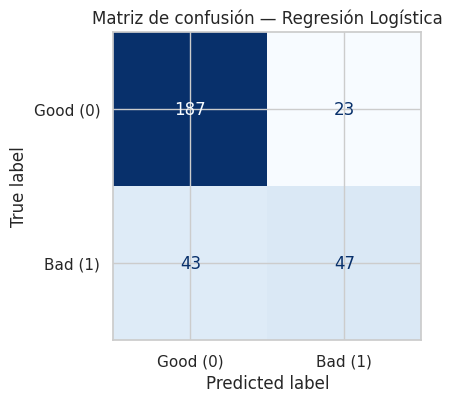

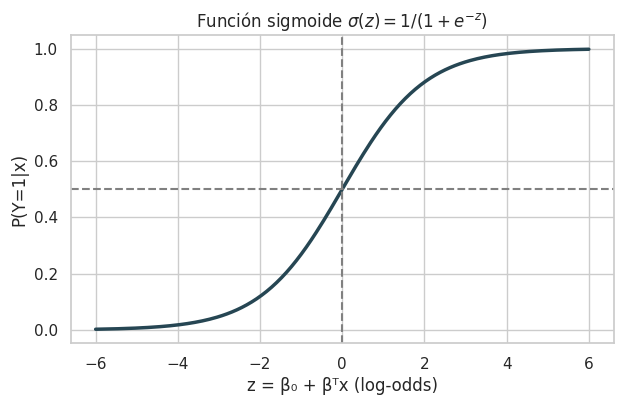

In [6]:
modelo_logit = evaluar_modelo(
    "Regresión Logística",
    LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE))

# Sigmoide ilustrativa
z = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 4))
plt.plot(z, 1/(1+np.exp(-z)), lw=2.5, color="#264653")
plt.axhline(0.5, ls="--", c="gray"); plt.axvline(0, ls="--", c="gray")
plt.title(r"Función sigmoide $\sigma(z) = 1/(1+e^{-z})$")
plt.xlabel("z = β₀ + βᵀx (log-odds)"); plt.ylabel("P(Y=1|x)")
plt.show()

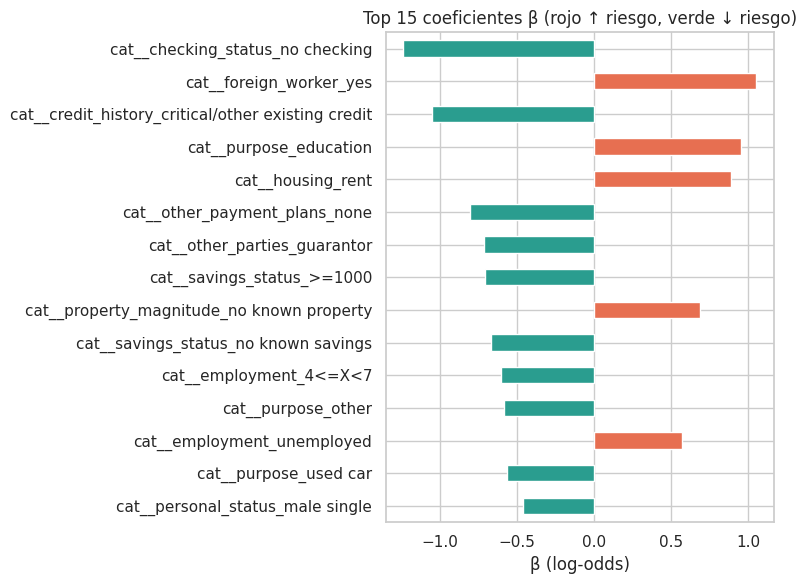

In [7]:
# Coeficientes más importantes (odds ratios)
feat_names = modelo_logit.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(modelo_logit.named_steps["clf"].coef_[0], index=feat_names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:15]

plt.figure(figsize=(8, 6))
colors = ["#e76f51" if c > 0 else "#2a9d8f" for c in top]
top.iloc[::-1].plot(kind="barh", color=colors[::-1])
plt.title("Top 15 coeficientes β (rojo ↑ riesgo, verde ↓ riesgo)")
plt.xlabel("β (log-odds)"); plt.tight_layout(); plt.show()

---
# 5. Análisis Discriminante (LDA y QDA)

### Teoría

Es un modelo **generativo**: modelamos $P(\mathbf{x}\mid Y=k)$ y usamos el **Teorema de Bayes** para invertir:

$$P(Y=k\mid\mathbf{x}) = \frac{\pi_k \, f_k(\mathbf{x})}{\sum_{l} \pi_l \, f_l(\mathbf{x})}$$

donde $\pi_k = P(Y=k)$ es la probabilidad a priori y $f_k$ la densidad condicional de clase.

**Supuesto gaussiano:** $\;\mathbf{X}\mid Y=k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$

$$f_k(\mathbf{x}) = \frac{1}{(2\pi)^{p/2}|\boldsymbol{\Sigma}_k|^{1/2}}\exp\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_k)^\top\boldsymbol{\Sigma}_k^{-1}(\mathbf{x}-\boldsymbol{\mu}_k)\right)$$

**LDA (Linear Discriminant Analysis):** supone covarianza común $\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}\;\forall k$. La función discriminante resulta **lineal**:

$$\delta_k(\mathbf{x}) = \mathbf{x}^\top\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_k - \tfrac{1}{2}\boldsymbol{\mu}_k^\top\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_k + \ln\pi_k$$

Se clasifica en la clase con mayor $\delta_k(\mathbf{x})$; la frontera $\delta_0(\mathbf{x}) = \delta_1(\mathbf{x})$ es un **hiperplano**.

**QDA (Quadratic DA):** permite $\boldsymbol{\Sigma}_k$ distintas por clase → frontera **cuadrática**:

$$\delta_k(\mathbf{x}) = -\tfrac{1}{2}\ln|\boldsymbol{\Sigma}_k| - \tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_k)^\top\boldsymbol{\Sigma}_k^{-1}(\mathbf{x}-\boldsymbol{\mu}_k) + \ln\pi_k$$

**Dato histórico:** el primer scorecard de crédito (Fair & Isaac, 1958) se basó en el discriminante de Fisher — LDA es literalmente el abuelo del score crediticio. ⚖️ *Trade-off:* LDA estima $O(p^2)$ parámetros; QDA estima $K$ matrices → más flexible pero más varianza.

===== LDA =====
              Accuracy: 0.7567
             Precision: 0.6133
                Recall: 0.5111
              F1-Score: 0.5576
                   AUC: 0.7980
    LogLoss (entropía): 0.4866


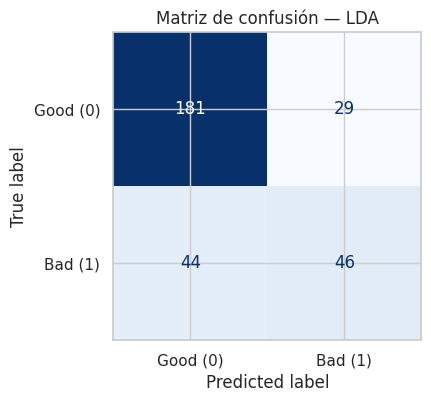

===== QDA =====
              Accuracy: 0.7833
             Precision: 0.6984
                Recall: 0.4889
              F1-Score: 0.5752
                   AUC: 0.8095
    LogLoss (entropía): 0.4856


In [8]:
modelo_lda = evaluar_modelo("LDA", LinearDiscriminantAnalysis())
modelo_qda = evaluar_modelo("QDA", QuadraticDiscriminantAnalysis(reg_param=0.3), plot_cm=False)

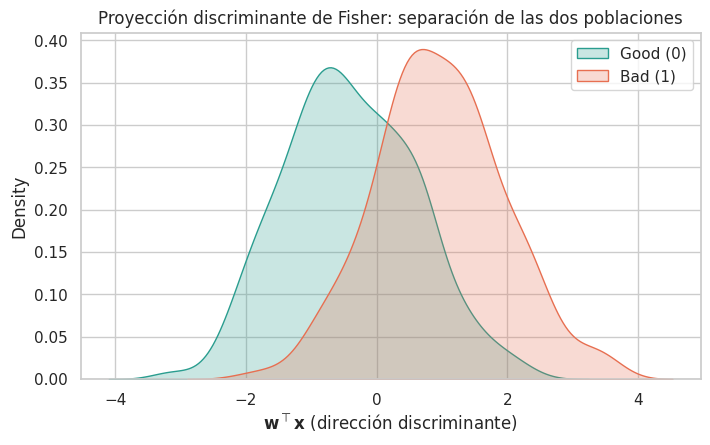

In [9]:
# Visualización: proyección de LDA (1D para 2 clases) — separación de poblaciones
X_train_t = modelo_lda.named_steps["prep"].transform(X_train)
proy = modelo_lda.named_steps["clf"].transform(
    X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t).ravel()

plt.figure(figsize=(8, 4.5))
sns.kdeplot(x=proy[y_train==0], fill=True, label="Good (0)", color="#2a9d8f")
sns.kdeplot(x=proy[y_train==1], fill=True, label="Bad (1)", color="#e76f51")
plt.title("Proyección discriminante de Fisher: separación de las dos poblaciones")
plt.xlabel(r"$\mathbf{w}^\top\mathbf{x}$ (dirección discriminante)"); plt.legend(); plt.show()

---
# 6. Naive Bayes

### Teoría

También generativo y bayesiano, pero con el supuesto **"naive" de independencia condicional** entre predictores dada la clase:

$$P(\mathbf{x}\mid Y=k) = \prod_{j=1}^{p} P(x_j \mid Y=k)$$

Entonces el clasificador es:

$$\hat{y} = \arg\max_k \; \pi_k \prod_{j=1}^{p} P(x_j\mid Y=k) \;=\; \arg\max_k\left[\ln\pi_k + \sum_{j=1}^p \ln P(x_j\mid Y=k)\right]$$

En la versión **Gaussian NB**, cada variable condicional es normal univariada:

$$P(x_j\mid Y=k) = \frac{1}{\sqrt{2\pi\sigma_{jk}^2}}\exp\left(-\frac{(x_j-\mu_{jk})^2}{2\sigma_{jk}^2}\right)$$

Es equivalente a QDA con **matrices de covarianza diagonales**. El supuesto de independencia es casi siempre falso (ingreso y monto del crédito están correlacionados), pero el modelo funciona sorprendentemente bien porque solo necesita ordenar bien las clases, no estimar probabilidades perfectas. Estima apenas $O(p)$ parámetros → muy poca varianza, mucho sesgo.

===== Naive Bayes =====
              Accuracy: 0.7000
             Precision: 0.5000
                Recall: 0.6333
              F1-Score: 0.5588
                   AUC: 0.7253
    LogLoss (entropía): 2.1811


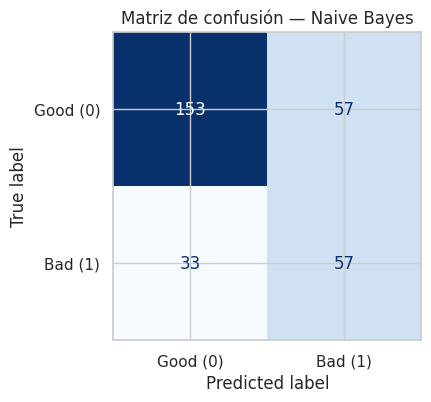

In [10]:
modelo_nb = evaluar_modelo("Naive Bayes", GaussianNB())

---
# 7. Árbol de Decisión (CART)

### Teoría

Particiona recursivamente el espacio de predictores en regiones $R_1,\dots,R_M$ mediante cortes binarios del tipo $x_j \le s$. La predicción en cada hoja es la clase mayoritaria.

**¿Cómo elegir el mejor corte?** Minimizando la **impureza** de los nodos hijos. Sea $\hat{p}_{mk}$ la proporción de clase $k$ en el nodo $m$:

**Entropía (de Shannon):**
$$H(m) = -\sum_{k} \hat{p}_{mk}\ln \hat{p}_{mk}$$

**Índice de Gini:**
$$G(m) = \sum_{k}\hat{p}_{mk}(1-\hat{p}_{mk}) = 1 - \sum_k \hat{p}_{mk}^2$$

Se elige el corte $(j, s)$ que maximiza la **ganancia de información**:

$$\Delta = H(\text{padre}) - \left[\frac{n_{izq}}{n}H(\text{izq}) + \frac{n_{der}}{n}H(\text{der})\right]$$

**Control de complejidad (poda):** se minimiza el costo-complejidad
$$C_\alpha(T) = \sum_{m=1}^{|T|} n_m \cdot H(m) + \alpha|T|$$
donde $|T|$ es el número de hojas y $\alpha$ penaliza árboles grandes. Un árbol sin restricción **sobreajusta** (varianza altísima); de ahí nacen los ensambles.

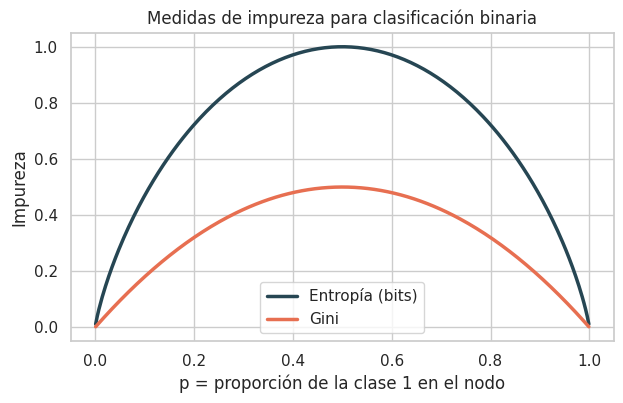

In [11]:
# Gráfica: entropía y Gini como funciones de p
p = np.linspace(0.001, 0.999, 300)
entropia = -(p*np.log2(p) + (1-p)*np.log2(1-p))
gini = 2*p*(1-p)

plt.figure(figsize=(7, 4))
plt.plot(p, entropia, label="Entropía (bits)", lw=2.5, color="#264653")
plt.plot(p, gini, label="Gini", lw=2.5, color="#e76f51")
plt.title("Medidas de impureza para clasificación binaria")
plt.xlabel("p = proporción de la clase 1 en el nodo"); plt.ylabel("Impureza")
plt.legend(); plt.show()

===== Árbol de Decisión =====
              Accuracy: 0.6767
             Precision: 0.4545
                Recall: 0.3889
              F1-Score: 0.4192
                   AUC: 0.7026
    LogLoss (entropía): 0.7198


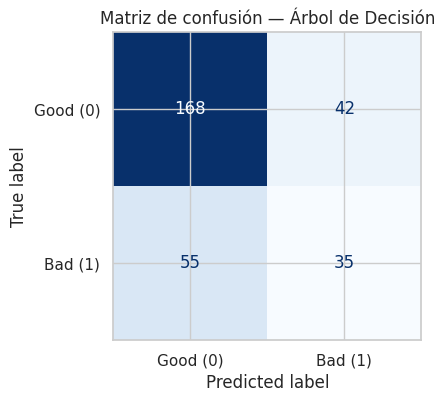

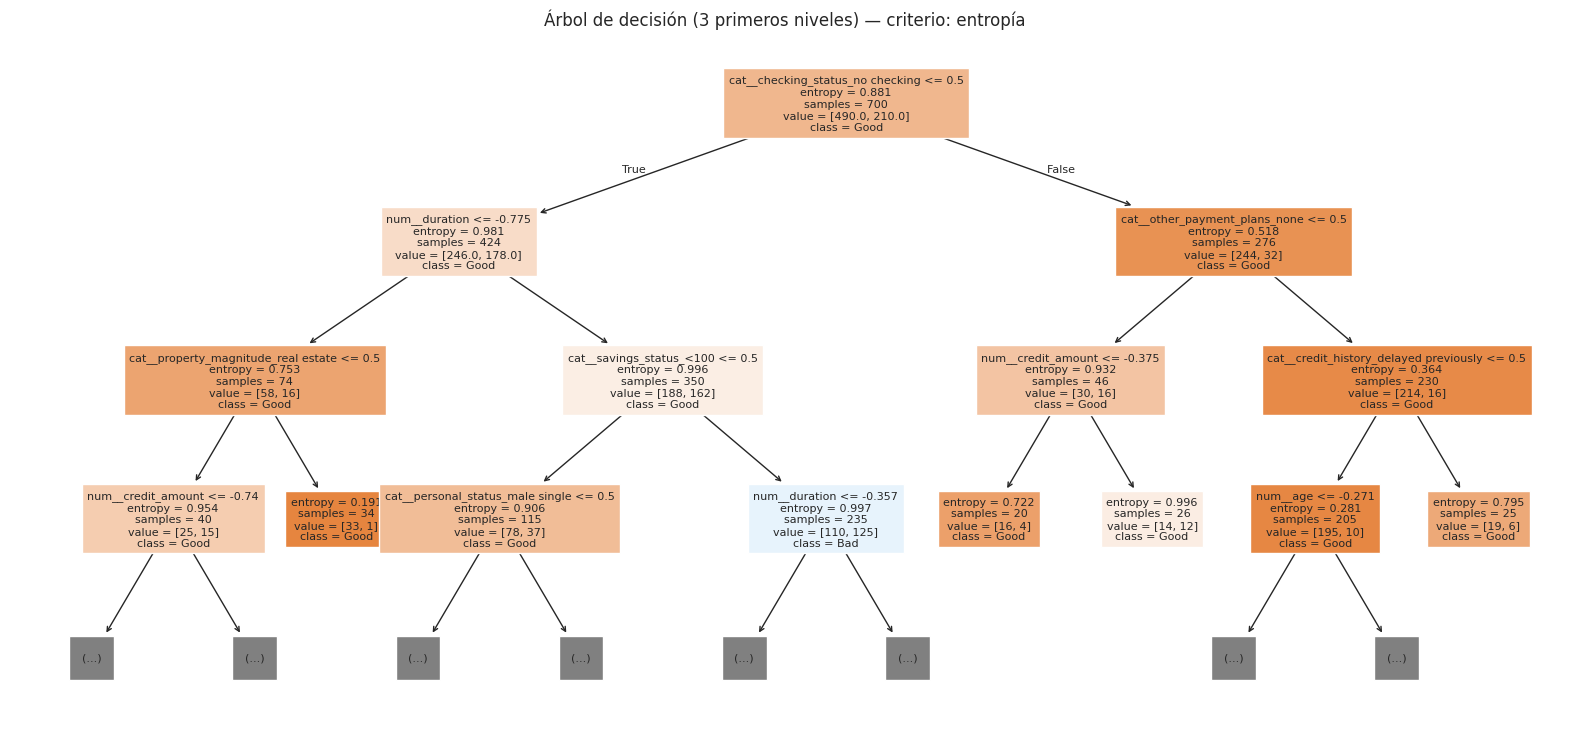

In [12]:
modelo_tree = evaluar_modelo(
    "Árbol de Decisión",
    DecisionTreeClassifier(criterion="entropy", max_depth=5,
                           min_samples_leaf=20, random_state=RANDOM_STATE))

# Visualizar el árbol (primeros niveles)
plt.figure(figsize=(20, 9))
plot_tree(modelo_tree.named_steps["clf"], max_depth=3, filled=True, fontsize=8,
          feature_names=modelo_tree.named_steps["prep"].get_feature_names_out(),
          class_names=["Good", "Bad"], impurity=True)
plt.title("Árbol de decisión (3 primeros niveles) — criterio: entropía")
plt.show()

---
# 8. Bagging (Bootstrap Aggregating)

### Teoría

Idea de Breiman (1996) para **reducir la varianza** de modelos inestables (como árboles profundos):

1. Generar $B$ muestras **bootstrap** $\mathcal{D}^{*b}$ (muestreo con reemplazo, tamaño $n$).
2. Entrenar un árbol $\hat{f}^{*b}$ en cada una.
3. Agregar por **voto mayoritario** (o promedio de probabilidades):

$$\hat{f}_{\text{bag}}(\mathbf{x}) = \frac{1}{B}\sum_{b=1}^{B}\hat{f}^{*b}(\mathbf{x})$$

**¿Por qué funciona?** Si tenemos $B$ estimadores con varianza $\sigma^2$ y correlación entre pares $\rho$:

$$\operatorname{Var}\big(\hat{f}_{\text{bag}}\big) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2$$

Al crecer $B$, el segundo término → 0. El límite es $\rho\sigma^2$: la correlación entre árboles es lo que impide reducir más la varianza (esto motiva Random Forest 👇). El sesgo **no** cambia.

**Bonus:** cada muestra bootstrap deja fuera $\approx (1-\tfrac1n)^n \to e^{-1} \approx 36.8\%$ de las observaciones → estimación **out-of-bag (OOB)** del error sin necesidad de test set.

===== Bagging =====
              Accuracy: 0.7433
             Precision: 0.5915
                Recall: 0.4667
              F1-Score: 0.5217
                   AUC: 0.7584
    LogLoss (entropía): 0.5382


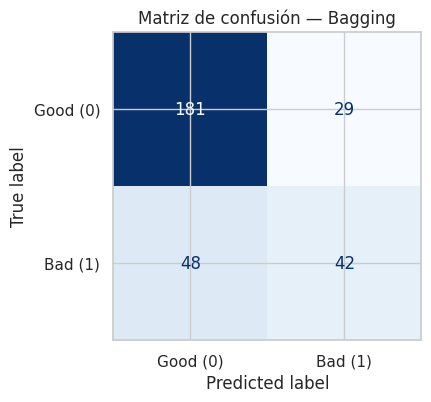


OOB score (estimación interna): 0.7543


In [13]:
modelo_bag = evaluar_modelo(
    "Bagging",
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                      n_estimators=200, oob_score=True,
                      random_state=RANDOM_STATE, n_jobs=-1))
print(f"\nOOB score (estimación interna): {modelo_bag.named_steps['clf'].oob_score_:.4f}")

---
# 9. Random Forest

### Teoría

Es **bagging + decorrelación**: en cada corte de cada árbol solo se consideran $m$ predictores elegidos al azar de los $p$ disponibles (típicamente $m = \sqrt{p}$ en clasificación).

$$\hat{f}_{\text{RF}}(\mathbf{x}) = \frac{1}{B}\sum_{b=1}^{B} T_b(\mathbf{x};\Theta_b), \qquad \Theta_b = (\text{bootstrap}_b, \text{subespacios aleatorios}_b)$$

Al restringir los predictores, los árboles quedan **menos correlacionados** (baja $\rho$ en la fórmula del bagging) → mayor reducción de varianza. Si hay un predictor dominante, sin esta restricción todos los árboles se parecerían.

**Importancia de variables** (Mean Decrease in Impurity): para cada variable $j$ se suma la ganancia de entropía/Gini de todos los cortes donde se usó, promediada sobre los $B$ árboles:

$$\text{Imp}(j) = \frac{1}{B}\sum_{b=1}^{B}\sum_{t\in T_b:\, v(t)=j} n_t\,\Delta_t$$

Esto da interpretabilidad al ensamble — clave para explicar el score al regulador.

===== Random Forest =====
              Accuracy: 0.7633
             Precision: 0.7021
                Recall: 0.3667
              F1-Score: 0.4818
                   AUC: 0.7952
    LogLoss (entropía): 0.5017


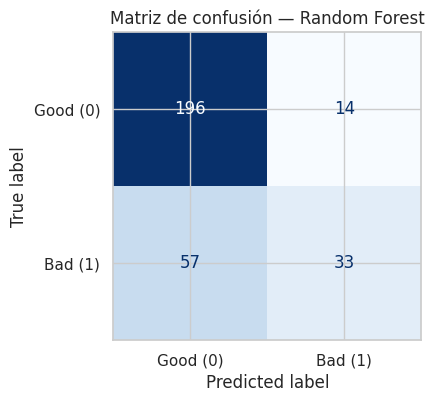

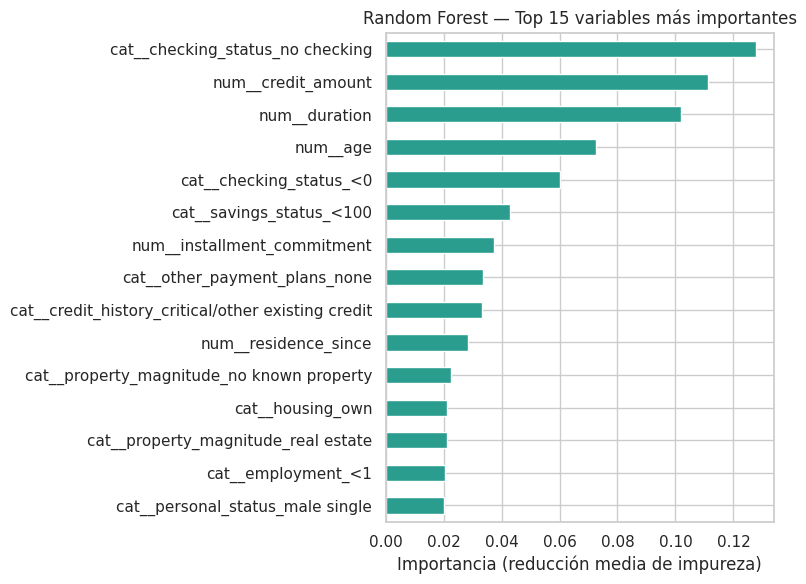

In [14]:
modelo_rf = evaluar_modelo(
    "Random Forest",
    RandomForestClassifier(n_estimators=400, max_features="sqrt",
                           min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1))

# Importancia de variables
imp = pd.Series(modelo_rf.named_steps["clf"].feature_importances_,
                index=modelo_rf.named_steps["prep"].get_feature_names_out()
               ).sort_values(ascending=False)[:15]
plt.figure(figsize=(8, 6))
imp.iloc[::-1].plot(kind="barh", color="#2a9d8f")
plt.title("Random Forest — Top 15 variables más importantes")
plt.xlabel("Importancia (reducción media de impureza)")
plt.tight_layout(); plt.show()

---
# 10. Boosting

### Teoría

A diferencia de bagging (paralelo, reduce varianza), boosting es **secuencial y reduce sesgo**: cada modelo nuevo se concentra en los errores del anterior.

### 10.1 AdaBoost (Freund & Schapire, 1997)

Con etiquetas $y_i\in\{-1,+1\}$ y pesos iniciales $w_i = 1/n$, en cada ronda $m$:

1. Entrenar clasificador débil $G_m$ con pesos $w_i$ y calcular el error ponderado: $\text{err}_m = \dfrac{\sum_i w_i\,\mathbb{1}(y_i\ne G_m(\mathbf{x}_i))}{\sum_i w_i}$
2. Peso del clasificador: $\alpha_m = \dfrac{1}{2}\ln\left(\dfrac{1-\text{err}_m}{\text{err}_m}\right)$
3. Reponderar (subir peso a los mal clasificados): $w_i \leftarrow w_i\,e^{-\alpha_m y_i G_m(\mathbf{x}_i)}$

Predicción final: $\;\hat{f}(\mathbf{x}) = \operatorname{sign}\left(\sum_{m=1}^{M}\alpha_m G_m(\mathbf{x})\right)$

Equivale a minimizar la **pérdida exponencial** $L(y,f) = e^{-y f(\mathbf{x})}$ por etapas.

### 10.2 Gradient Boosting (Friedman, 2001)

Generalización: **descenso de gradiente en el espacio de funciones**. Para una pérdida $L$ (aquí la log-loss):

$$f_m(\mathbf{x}) = f_{m-1}(\mathbf{x}) + \nu\cdot h_m(\mathbf{x}), \qquad h_m \approx -\left.\frac{\partial L(y, f)}{\partial f}\right|_{f=f_{m-1}}$$

Cada árbol $h_m$ se ajusta a los **pseudo-residuales** (el gradiente negativo). $\nu\in(0,1]$ es el *learning rate* (shrinkage): valores pequeños + más árboles = mejor generalización. XGBoost/LightGBM son versiones optimizadas de esta idea y dominan el scoring crediticio moderno.

===== AdaBoost =====
              Accuracy: 0.7567
             Precision: 0.6491
                Recall: 0.4111
              F1-Score: 0.5034
                   AUC: 0.7967
    LogLoss (entropía): 0.5980
===== Gradient Boosting =====
              Accuracy: 0.7733
             Precision: 0.6833
                Recall: 0.4556
              F1-Score: 0.5467
                   AUC: 0.7938
    LogLoss (entropía): 0.5000


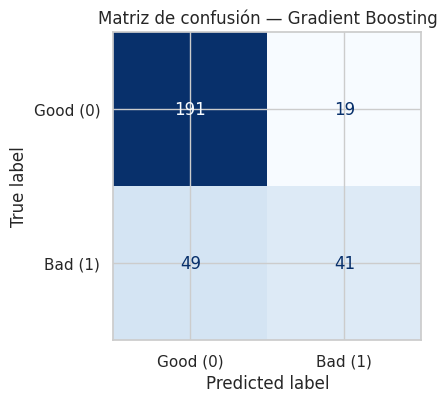

In [15]:
modelo_ada = evaluar_modelo(
    "AdaBoost",
    AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE),
    plot_cm=False)

modelo_gb = evaluar_modelo(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                               max_depth=3, subsample=0.8, random_state=RANDOM_STATE))

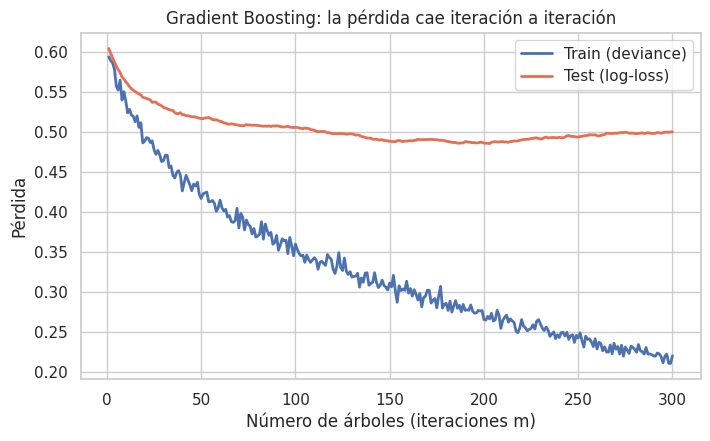

In [16]:
# Curva de aprendizaje del boosting: error vs número de árboles
gb = modelo_gb.named_steps["clf"]
X_test_t = modelo_gb.named_steps["prep"].transform(X_test)
test_dev = [log_loss(y_test, p[:, 1]) for p in gb.staged_predict_proba(X_test_t)]

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(1, len(gb.train_score_)+1), gb.train_score_/2, label="Train (deviance)", lw=2)
plt.plot(np.arange(1, len(test_dev)+1), test_dev, label="Test (log-loss)", lw=2, color="#e76f51")
plt.title("Gradient Boosting: la pérdida cae iteración a iteración")
plt.xlabel("Número de árboles (iteraciones m)"); plt.ylabel("Pérdida")
plt.legend(); plt.show()

---
# 11. Máquina de Soporte Vectorial (SVM)

### Teoría

**Idea:** encontrar el hiperplano $\mathbf{w}^\top\mathbf{x} + b = 0$ que separa las clases con el **margen máximo**. Con $y_i\in\{-1,+1\}$, el margen geométrico es $2/\lVert\mathbf{w}\rVert$, y el problema (margen suave) es:

$$\min_{\mathbf{w},b,\xi}\;\frac{1}{2}\lVert\mathbf{w}\rVert^2 + C\sum_{i=1}^n \xi_i \quad\text{s.a.}\quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1 - \xi_i,\;\; \xi_i\ge 0$$

Las $\xi_i$ (variables de holgura) permiten violaciones del margen; $C$ controla el trade-off sesgo-varianza. Equivale a minimizar la **pérdida hinge** regularizada:

$$\sum_{i=1}^n \max\big(0,\, 1 - y_i f(\mathbf{x}_i)\big) + \lambda\lVert\mathbf{w}\rVert^2$$

**El problema dual** solo depende de productos internos $\mathbf{x}_i^\top\mathbf{x}_j$:

$$\max_{\boldsymbol\alpha}\;\sum_i \alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j\,\langle\mathbf{x}_i,\mathbf{x}_j\rangle \quad\text{s.a. } 0\le\alpha_i\le C,\;\textstyle\sum_i\alpha_i y_i = 0$$

**Truco del kernel:** reemplazamos $\langle\mathbf{x}_i,\mathbf{x}_j\rangle$ por $K(\mathbf{x}_i,\mathbf{x}_j) = \langle\phi(\mathbf{x}_i),\phi(\mathbf{x}_j)\rangle$ para obtener fronteras no lineales sin calcular $\phi$ explícitamente. El más usado es el **RBF (gaussiano)**:

$$K(\mathbf{x},\mathbf{x}') = \exp\big(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2\big)$$

Solo los puntos con $\alpha_i > 0$ (los **vectores de soporte**, cerca de la frontera) definen el modelo. Nota: la SVM no produce probabilidades naturalmente; se calibran con el método de Platt (`probability=True`).

===== SVM (RBF) =====
              Accuracy: 0.7733
             Precision: 0.7115
                Recall: 0.4111
              F1-Score: 0.5211
                   AUC: 0.8025
    LogLoss (entropía): 0.4852


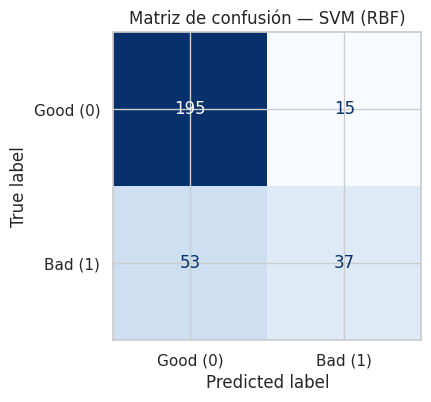

In [17]:
modelo_svm = evaluar_modelo(
    "SVM (RBF)",
    SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE))

---
# 12. Red Neuronal (Perceptrón Multicapa, MLP)

### Teoría

Composición de transformaciones afines + no linealidades. Para una red con capas ocultas $\ell = 1,\dots,L$:

$$\mathbf{a}^{(0)} = \mathbf{x}, \qquad \mathbf{a}^{(\ell)} = g\big(\mathbf{W}^{(\ell)}\mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)}\big), \qquad \hat{p} = \sigma\big(\mathbf{w}^{(L+1)\top}\mathbf{a}^{(L)} + b\big)$$

Con activación **ReLU**: $g(z) = \max(0, z)$. La capa de salida usa la sigmoide → probabilidad de default.

**Entrenamiento:** minimizar la entropía cruzada (¡la misma log-loss de siempre!)

$$J(\theta) = -\frac{1}{n}\sum_i\big[y_i\ln\hat{p}_i + (1-y_i)\ln(1-\hat{p}_i)\big] + \alpha\lVert\theta\rVert_2^2$$

mediante **backpropagation** (regla de la cadena para calcular gradientes capa por capa):

$$\frac{\partial J}{\partial \mathbf{W}^{(\ell)}} = \boldsymbol{\delta}^{(\ell)}\,\mathbf{a}^{(\ell-1)\top}, \qquad \boldsymbol{\delta}^{(\ell)} = \big(\mathbf{W}^{(\ell+1)\top}\boldsymbol{\delta}^{(\ell+1)}\big)\odot g'(\mathbf{z}^{(\ell)})$$

y descenso de gradiente estocástico (aquí, el optimizador **Adam**):
$$\theta_{t+1} = \theta_t - \eta\,\hat{\mathbf{m}}_t/\big(\sqrt{\hat{\mathbf{v}}_t}+\epsilon\big)$$

**Teorema de aproximación universal:** con suficientes neuronas, un MLP de una capa oculta puede aproximar cualquier función continua. En crédito, su desventaja es la **baja interpretabilidad** (problema de "caja negra" ante el regulador).

===== Red Neuronal (MLP) =====
              Accuracy: 0.7267
             Precision: 0.6333
                Recall: 0.2111
              F1-Score: 0.3167
                   AUC: 0.7668
    LogLoss (entropía): 0.5253


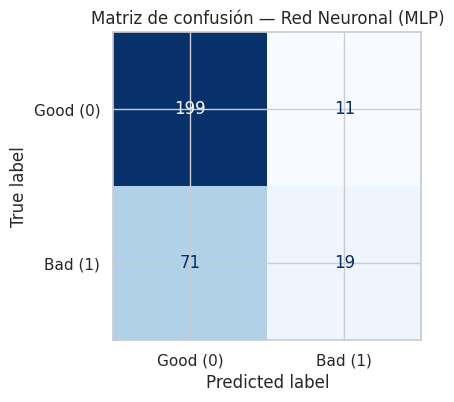

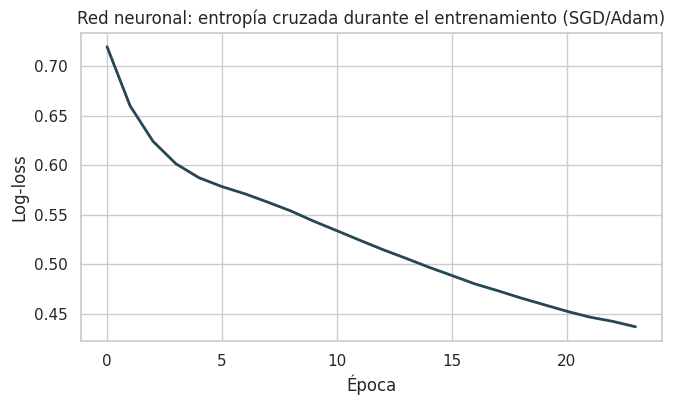

In [18]:
modelo_mlp = evaluar_modelo(
    "Red Neuronal (MLP)",
    MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                  alpha=1e-3, max_iter=800, early_stopping=True, random_state=RANDOM_STATE))

# Curva de pérdida durante el entrenamiento
plt.figure(figsize=(7.5, 4))
plt.plot(modelo_mlp.named_steps["clf"].loss_curve_, lw=2, color="#264653")
plt.title("Red neuronal: entropía cruzada durante el entrenamiento (SGD/Adam)")
plt.xlabel("Época"); plt.ylabel("Log-loss"); plt.show()

---
# 13. 🏆 Comparación final de todos los modelos

Reunimos las métricas de test de los 10 modelos: **Accuracy, Precision, Recall, F1-Score, AUC y Log-Loss (entropía cruzada)**.

In [19]:
# ==========================================================
# Tabla comparativa
# ==========================================================
tabla = pd.DataFrame(resultados).T.sort_values("F1-Score", ascending=False)
display(tabla.round(4).style
        .background_gradient(subset=["Accuracy","F1-Score","AUC"], cmap="Greens")
        .background_gradient(subset=["LogLoss (entropía)"], cmap="Reds")
        .format("{:.4f}"))

,Accuracy,Precision,Recall,F1-Score,AUC,LogLoss (entropía)
Regresión Logística,0.7800,0.6714,0.5222,0.5875,0.8019,0.4800
QDA,0.7833,0.6984,0.4889,0.5752,0.8095,0.4856
Naive Bayes,0.7000,0.5000,0.6333,0.5588,0.7253,2.1811
LDA,0.7567,0.6133,0.5111,0.5576,0.7980,0.4866
Gradient Boosting,0.7733,0.6833,0.4556,0.5467,0.7938,0.5000
Bagging,0.7433,0.5915,0.4667,0.5217,0.7584,0.5382
SVM (RBF),0.7733,0.7115,0.4111,0.5211,0.8025,0.4852
AdaBoost,0.7567,0.6491,0.4111,0.5034,0.7967,0.5980
Random Forest,0.7633,0.7021,0.3667,0.4818,0.7952,0.5017
Árbol de Decisión,0.6767,0.4545,0.3889,0.4192,0.7026,0.7198


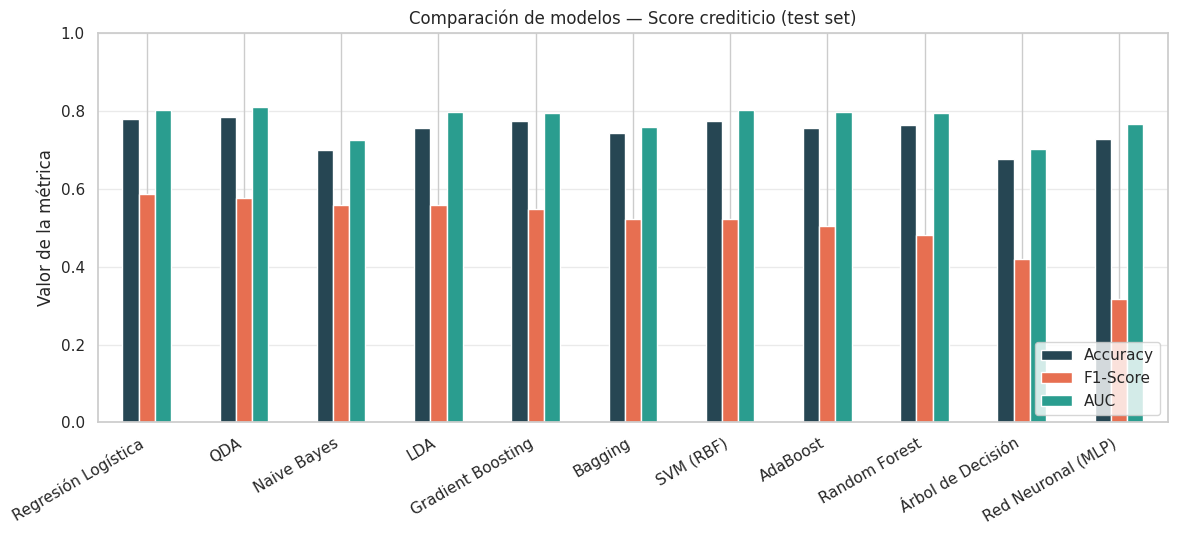

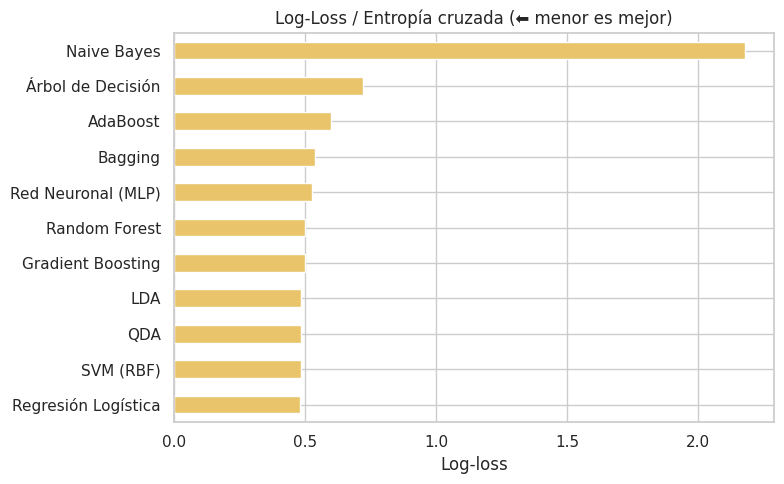

In [20]:
# Gráfica comparativa de barras: Accuracy, F1 y AUC
tabla[["Accuracy", "F1-Score", "AUC"]].plot(kind="bar", figsize=(12, 5.5),
                                            color=["#264653", "#e76f51", "#2a9d8f"])
plt.title("Comparación de modelos — Score crediticio (test set)")
plt.ylabel("Valor de la métrica"); plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right"); plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.4); plt.tight_layout(); plt.show()

# Log-loss aparte (menor = mejor)
tabla["LogLoss (entropía)"].sort_values().plot(kind="barh", figsize=(8, 5), color="#e9c46a")
plt.title("Log-Loss / Entropía cruzada (⬅ menor es mejor)")
plt.xlabel("Log-loss"); plt.tight_layout(); plt.show()

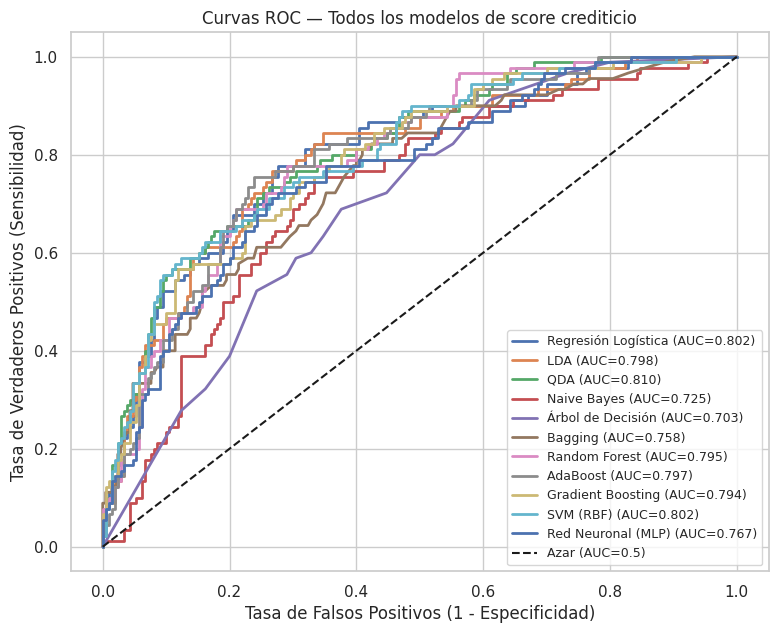

In [21]:
# ==========================================================
# Curvas ROC de todos los modelos
# ==========================================================
plt.figure(figsize=(9, 7))
for nombre, y_prob in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC={resultados[nombre]['AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Azar (AUC=0.5)")
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curvas ROC — Todos los modelos de score crediticio")
plt.legend(fontsize=9, loc="lower right"); plt.show()

## 14. Conclusiones y discusión para la clase

**Sobre los resultados típicos en este dataset:**
- La **regresión logística y LDA** suelen quedar sorprendentemente arriba: con $n=1000$ y señal mayormente lineal, los modelos simples con poco sesgo adicional ganan (navaja de Occam estadística).
- **Gradient Boosting y Random Forest** compiten por el mejor AUC/F1 — capturan interacciones y no-linealidades.
- **Naive Bayes** suele tener el peor log-loss: sus probabilidades están mal calibradas (por la independencia falsa), aunque ordene razonablemente.
- El **árbol individual** pierde contra sus ensambles → evidencia empírica de la reducción de varianza.

**Trade-offs clave en crédito (tema de discusión):**

| Criterio | Ganador |
|---|---|
| Interpretabilidad / regulador (SFC, Basilea) | Regresión logística, LDA, árbol |
| Poder predictivo puro | Boosting, Random Forest |
| Probabilidades bien calibradas | Logística, Gradient Boosting |
| Costo computacional bajo | Naive Bayes, LDA |

**Ideas de tarea/extensión:**
1. Cambiar el umbral de 0.5 usando una **matriz de costos** (un FN —prestar a un mal pagador— cuesta más que un FP).
2. Calibrar probabilidades (Platt / isotónica) y graficar *reliability diagrams*.
3. Construir el **scorecard en puntos**: $\text{Score} = 600 - \frac{20}{\ln 2}\ln(\text{odds})$.
4. Validación cruzada k-fold y *grid search* de hiperparámetros.
5. Probar XGBoost / LightGBM y comparar con `GradientBoostingClassifier`.

---
*Notebook educativo — Modelos de clasificación para score crediticio. Dataset: German Credit (Statlog), OpenML.*